# NL-1 aside — test-time training you can *see*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/nested-learning/nl1-aside-image-ttt.ipynb)

*A second companion to [NL-1](nl1-test-time-learning.ipynb), for when the random key/value toy ([where the self-supervised error comes from](nl1-aside-self-supervision.ipynb)) feels abstract. This is the **original Test-Time Training** ([Sun, Wang, Liu, Miller, Efros & Hardt, ICML 2020](https://arxiv.org/abs/1909.13231)), the image-classification ancestor of NL-1's sequence TTT. The lineage is literal, not just conceptual: Yu Sun is first author on both, five years apart. Here you can watch "where does the self-supervised error come from?" play out on real digits.*

Runs on CPU in a couple of minutes, with a one-time ~11 MB MNIST download (cached locally).

The trick, in one breath: take a digit image, **rotate it by 0°/90°/180°/270° yourself**, and train the network to predict *which rotation you applied*. The rotation is a **free label you manufactured from the image** — no human annotation. At test time, on weird/corrupted images, the network adapts its features by getting better at that rotation task — using **no class labels at all** — and its digit-recognition accuracy recovers.

Two heads on a shared trunk: **classification** (outer loss, real labels, training only) and **rotation** (inner loss, self-supervised, runs at test time).


## 1. The data and the self-supervised task

MNIST digits. The classification label (which digit) is the *outer* supervision — used only in training. The **rotation label is self-supervised**: we rotate each image by a known multiple of 90° and the angle index `0,1,2,3` is the target.

downloading train-images-idx3-ubyte.gz (one time)...


downloading train-labels-idx1-ubyte.gz (one time)...


downloading t10k-images-idx3-ubyte.gz (one time)...


downloading t10k-labels-idx1-ubyte.gz (one time)...


MNIST: (12000, 28, 28) train / (2000, 28, 28) test


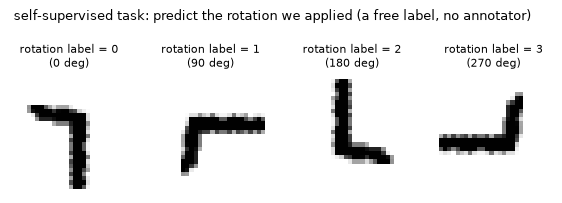

In [1]:
import gzip
import os
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def prepare_mnist():
    root = os.path.expanduser("~/.cache/cl-course-data")
    os.makedirs(root, exist_ok=True)
    base = "https://ossci-datasets.s3.amazonaws.com/mnist/"
    files = {
        "trX": "train-images-idx3-ubyte.gz",
        "trY": "train-labels-idx1-ubyte.gz",
        "teX": "t10k-images-idx3-ubyte.gz",
        "teY": "t10k-labels-idx1-ubyte.gz",
    }

    def load(fn, img):
        p = os.path.join(root, fn)
        if not os.path.exists(p):
            print("downloading", fn, "(one time)...")
            urllib.request.urlretrieve(base + fn, p)
        with gzip.open(p, "rb") as f:
            d = f.read()
        return (
            np.frombuffer(d, np.uint8, offset=16).reshape(-1, 28, 28) if img else np.frombuffer(d, np.uint8, offset=8)
        )

    return (load(files["trX"], 1), load(files["trY"], 0), load(files["teX"], 1), load(files["teY"], 0))


trXn, trYn, teXn, teYn = prepare_mnist()
torch.manual_seed(0)
trX = torch.tensor(trXn / 255.0, dtype=torch.float32)
trY = torch.tensor(trYn.copy(), dtype=torch.long)
teX = torch.tensor(teXn / 255.0, dtype=torch.float32)
teY = torch.tensor(teYn.copy(), dtype=torch.long)
tr = torch.randperm(len(trX))[:12000]
trX, trY = trX[tr], trY[tr]  # subsample for CPU speed
te = torch.randperm(len(teX))[:2000]
teX, teY = teX[te], teY[te]
print("MNIST:", tuple(trX.shape), "train /", tuple(teX.shape), "test")

# the self-supervised task: predict which rotation was applied (the angle is the label)
img = teX[1]
fig, ax = plt.subplots(1, 4, figsize=(7, 2))
for k in range(4):
    ax[k].imshow(torch.rot90(img, k, [0, 1]), cmap="gray_r")
    ax[k].axis("off")
    ax[k].set_title(f"rotation label = {k}\n({k * 90} deg)", fontsize=8)
fig.suptitle("self-supervised task: predict the rotation we applied (a free label, no annotator)", y=1.12, fontsize=9)
plt.show()

## 2. Train two heads on clean digits

A shared convolutional **trunk** feeds two linear heads:

- **classification head** — trained on the real digit labels (the **outer**, supervised loss);
- **rotation head** — trained to predict the rotation of a rotated copy (the **inner**, self-supervised loss).

Both losses train the *shared trunk*, so the trunk learns features that serve recognition **and** are sensitive to image orientation. That shared trunk is what test-time adaptation will later tune.

In [2]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.cls = nn.Linear(64, 10)  # outer head (digit) -- needs labels
        self.rot = nn.Linear(64, 4)  # inner head (rotation) -- self-supervised

    def feat(self, x):
        return self.trunk(x.unsqueeze(1))


def rot_batch(x):  # 4 rotations of each image; the angle index is the label
    xs = [x] + [torch.rot90(x, k, [1, 2]) for k in (1, 2, 3)]
    return torch.cat(xs), torch.cat([torch.full((len(x),), k) for k in range(4)])


torch.manual_seed(0)
net = Net()
opt = torch.optim.Adam(net.parameters(), 1e-3)
for epoch in range(3):
    net.train()
    for i in range(0, len(trX), 128):
        xb, yb = trX[i : i + 128], trY[i : i + 128]
        cls_loss = F.cross_entropy(net.cls(net.feat(xb)), yb)  # OUTER: real digit labels
        rx, ry = rot_batch(xb)
        rot_loss = F.cross_entropy(net.rot(net.feat(rx)), ry)  # INNER: self-supervised rotation
        opt.zero_grad()
        (cls_loss + rot_loss).backward()
        opt.step()


def accuracy(model, X, Y):
    model.eval()
    with torch.no_grad():
        preds = torch.cat([model.cls(model.feat(X[i : i + 256])).argmax(1) for i in range(0, len(X), 256)])
    return (preds == Y).float().mean().item()


clean_acc = accuracy(net, teX, teY)
print(f"clean test accuracy: {clean_acc:.3f}")

clean test accuracy: 0.979


## 3. A distribution shift breaks it

Now the test images are **corrupted** — heavy noise the model never saw in training (a stand-in for the real-world shifts TTT was built for: blur, weather, sensor noise…). The features no longer match what the classifier expects, and accuracy collapses toward chance.

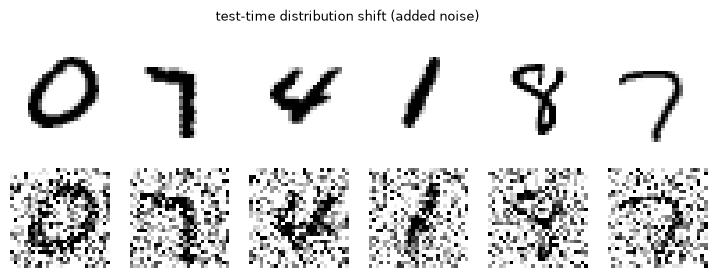

clean accuracy 0.979   ->   corrupted accuracy 0.110  (no adaptation)


In [3]:
def corrupt(X, std=0.6):
    torch.manual_seed(1)
    return (X + std * torch.randn_like(X)).clamp(0, 1)


teXc = corrupt(teX)
fig, ax = plt.subplots(2, 6, figsize=(9, 3))
for j in range(6):
    ax[0, j].imshow(teX[j], cmap="gray_r")
    ax[0, j].axis("off")
    ax[1, j].imshow(teXc[j], cmap="gray_r")
    ax[1, j].axis("off")
ax[0, 0].set_ylabel("clean", fontsize=8)
ax[1, 0].set_ylabel("corrupted", fontsize=8)
fig.suptitle("test-time distribution shift (added noise)", fontsize=9)
plt.show()

corrupted_acc = accuracy(net, teXc, teY)
print(f"clean accuracy {clean_acc:.3f}   ->   corrupted accuracy {corrupted_acc:.3f}  (no adaptation)")

## 4. Test-time training: fix it with **no labels**

Here is the whole point. We adapt the network on the **corrupted test images themselves**, by gradient descent on the **rotation loss only** — rotating each corrupted image and predicting the angle. We *never* touch the digit labels. Improving the self-supervised task pulls the shared trunk's features back into a sensible range for this corrupted distribution, and the (untouched) classification head rides along — its accuracy recovers.

The error signal at test time is manufactured from the data (the rotations *we* applied), exactly as in [NL-1](nl1-test-time-learning.ipynb) §1's reconstruction loss.

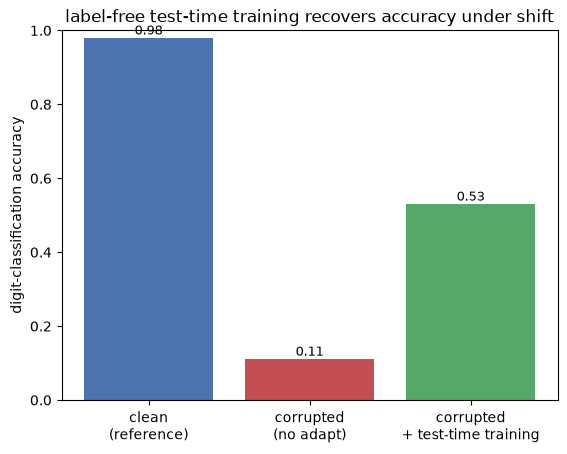

corrupted 0.110  ->  after test-time training 0.530  (+0.42, using zero class labels)


In [4]:
import copy

adapted = copy.deepcopy(net)
opt_t = torch.optim.Adam(adapted.parameters(), 1e-3)
for epoch in range(3):
    adapted.train()
    for i in range(0, len(teXc), 128):
        rx, ry = rot_batch(teXc[i : i + 128])  # rotations of CORRUPTED test images
        loss = F.cross_entropy(adapted.rot(adapted.feat(rx)), ry)  # self-supervised: NO digit labels
        opt_t.zero_grad()
        loss.backward()
        opt_t.step()

ttt_acc = accuracy(adapted, teXc, teY)
labels = ["clean\n(reference)", "corrupted\n(no adapt)", "corrupted\n+ test-time training"]
vals = [clean_acc, corrupted_acc, ttt_acc]
plt.bar(labels, vals, color=["#4c72b0", "#c44e52", "#55a868"])
for i, v in enumerate(vals):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
plt.ylabel("digit-classification accuracy")
plt.ylim(0, 1)
plt.title("label-free test-time training recovers accuracy under shift")
plt.show()
print(
    f"corrupted {corrupted_acc:.3f}  ->  after test-time training {ttt_acc:.3f}  "
    f"(+{ttt_acc - corrupted_acc:.2f}, using zero class labels)"
)

## So where did the error come from? (tangible version)

Exactly the two levels from the [random-vector aside](nl1-aside-self-supervision.ipynb), now visible:

- **Inner loss:** self-supervised, no labels, runs at test time. Predict the rotation *we* applied. The target is made from the image (we chose the angle), so it needs no annotation. This is what adapted the network to the corrupted images.
- **Outer loss:** supervised, labels, training only. Digit classification. During training it shaped the shared trunk so that *getting better at rotation also keeps features good for classification*. That alignment is what makes the label-free inner loop *useful*. (With a random trunk, adapting the rotation task would do nothing for classification — same lesson as §A of the other aside.)

So it's **meta-learning**: the outer loop (labels, training) configures a self-supervised inner loop so that at test time the inner loop alone, *no labels*, can adapt the model to new, shifted data. This is the same idea as [NL-1](nl1-test-time-learning.ipynb)'s sequence TTT; the only change is the form of the self-supervised loss (predict-the-rotation here, reconstruct-a-token-view there). At test time the error signal comes entirely from the rotations we manufactured.